In [9]:
pip install pandas nltk scikit-learn beautifulsoup4 transformers torch joblib

Note: you may need to restart the kernel to use updated packages.


In [10]:
import re
import joblib
import pandas as pd
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Advanced NLP
from transformers import pipeline

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to C:\Users\Acer Swift
[nltk_data]     X\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Acer Swift
[nltk_data]     X\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Acer Swift
[nltk_data]     X\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [13]:
# Load dataset

df = pd.read_csv(r"C:\Users\Acer Swift X\Downloads\nlp project\frontend_StreamlitApp\IMDB Dataset.csv")

df = df.rename(columns={
    "review": "text",
    "sentiment": "label"
})

print(df.head())

                                                text     label
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [14]:
# Preprocessing

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = BeautifulSoup(str(text), "html.parser").get_text()

    text = text.lower()

    text = re.sub(r"[^a-z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

In [15]:
# Train test split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
# Feature extraction 

bow_vectorizer = CountVectorizer(max_features=10000)
tfidf_vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [51]:
# Model Training

models = {
    "BoW + Naive Bayes": (MultinomialNB(), X_train_bow, X_test_bow),
    "BoW + SVM": (LinearSVC(), X_train_bow, X_test_bow),
    "TF-IDF + Naive Bayes": (MultinomialNB(), X_train_tfidf, X_test_tfidf),
    "TF-IDF + SVM": (LinearSVC(), X_train_tfidf, X_test_tfidf)
}

results = []
best_model = None
best_name = None
best_accuracy = 0

In [86]:
# Evaluation

trained_models = {}
results = []
trained_models = {}

for name, (model, Xtr, Xte) in models.items():
    print("\n==============================")
    print("Training:", name)
    print("==============================")

    model.fit(Xtr, y_train)
    predictions = model.predict(Xte)

    trained_models[name] = model

    accuracy = accuracy_score(y_test, predictions)
    report = classification_report(y_test, predictions, output_dict=True)

    print("Accuracy:", accuracy)
    print(classification_report(y_test, predictions))

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    })


Training: BoW + Naive Bayes
Accuracy: 0.8513
              precision    recall  f1-score   support

    negative       0.84      0.86      0.85      5000
    positive       0.86      0.84      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


Training: BoW + SVM


c:\Users\Acer Swift X\miniconda3\envs\tfgpu\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.8482
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      5000
    positive       0.85      0.85      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


Training: TF-IDF + Naive Bayes
Accuracy: 0.8734
              precision    recall  f1-score   support

    negative       0.89      0.85      0.87      5000
    positive       0.86      0.89      0.88      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


Training: TF-IDF + SVM
Accuracy: 0.8943
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      5000
    positive       0.89      0.90      0.90      5000

    accuracy                           0.89     10000
   macro avg       0.

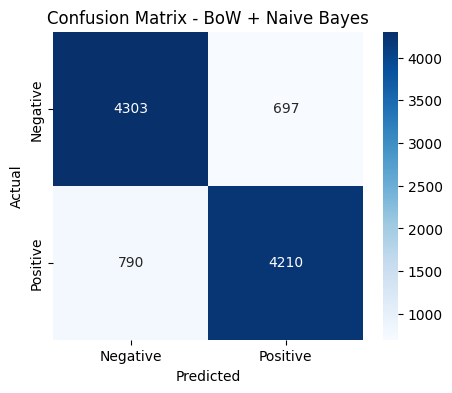

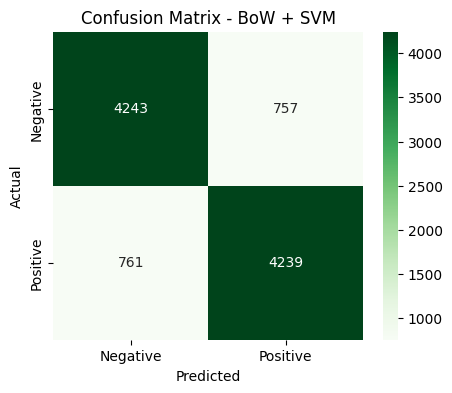

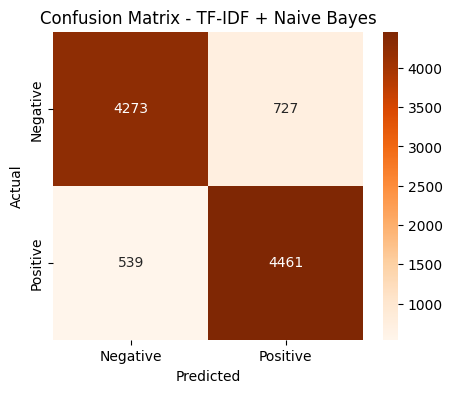

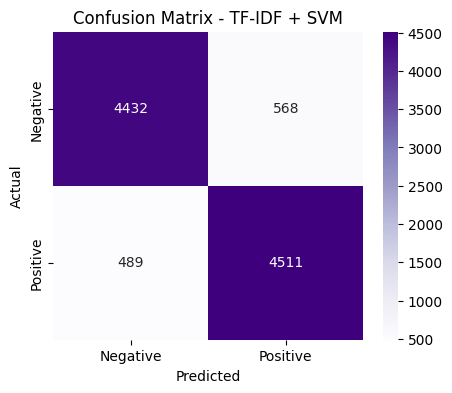

In [87]:
# Confusion matrix for each model

color_maps = {
    "BoW + Naive Bayes": "Blues",
    "BoW + SVM": "Greens",
    "TF-IDF + Naive Bayes": "Oranges",
    "TF-IDF + SVM": "Purples"
}

for name, (model, Xtr, Xte) in models.items():

    predictions = model.predict(Xte)
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=color_maps[name],
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [88]:
# Comparison table

comparison_table = pd.DataFrame(results)

print("Model Comparison")
print(comparison_table)

Model Comparison
                  Model  Accuracy  Precision  Recall  F1-Score
0     BoW + Naive Bayes    0.8513   0.851422  0.8513  0.851287
1             BoW + SVM    0.8482   0.848200  0.8482  0.848200
2  TF-IDF + Naive Bayes    0.8734   0.873929  0.8734  0.873355
3          TF-IDF + SVM    0.8943   0.894398  0.8943  0.894293


In [19]:
# The best model

best_row = comparison_table.loc[comparison_table["F1-Score"].idxmax()]
best_name = best_row["Model"]
best_model = trained_models[best_name]

# Select correct vectorizer
if "BoW" in best_name:
    best_vectorizer = bow_vectorizer
else:
    best_vectorizer = tfidf_vectorizer

# Save best model and vectorizer
joblib.dump(best_model, "best_model.pkl")
joblib.dump(best_vectorizer, "best_vectorizer.pkl")

print("Best Model:", best_name)
print(f"Accuracy : {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall   : {best_row['Recall']:.4f}")
print(f"F1-Score : {best_row['F1-Score']:.4f}")
print("\nSaved best_model.pkl and best_vectorizer.pkl")

Best Model: TF-IDF + SVM
Accuracy : 0.8943
Precision: 0.8944
Recall   : 0.8943
F1-Score : 0.8943

Saved best_model.pkl and best_vectorizer.pkl


ADVANCED NLP: DISTILBERT SENTIMENT ANALYSIS

In [ ]:
# Load DistilBERT Sentiment Model

bert_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    framework="pt",
    device=-1
)

print("DistilBERT model loaded successfully!")

Device set to use cpu


DistilBERT model loaded successfully!


In [57]:
# Translation function for non-English reviews

from deep_translator import GoogleTranslator

def translate_to_english(text):
    try:
        return GoogleTranslator(
            source="auto",
            target="en"
        ).translate(text)
    except:
        return text

In [ ]:
# BERT Prediction Function

def bert_predict_sentiment(text):

    result = bert_model(
        str(text),
        truncation=True,
        max_length=512
    )[0]

    sentiment = result["label"].lower()  # positive or negative
    confidence = result["score"]

    return sentiment, confidence

In [ ]:
# Test BERT with Sample Reviews

sample_reviews = [
    "This movie was amazing.",
    "The film was boring and too slow.",
    "Filem ini sangat bagus dan menarik.",
    "这部电影很好看，我很喜欢。",
    "The acting was okay but the story was average."
]

for review in sample_reviews:

    translated = translate_to_english(review)

    sentiment, confidence = bert_predict_sentiment(translated)

    print("\nOriginal:", review)
    print("Translated:", translated)
    print("Prediction:", sentiment)
    print("Confidence:", round(confidence, 4))


Original: This movie was amazing.
Translated: This movie was amazing.
Prediction: positive
Confidence: 0.9999

Original: The film was boring and too slow.
Translated: The film was boring and too slow.
Prediction: negative
Confidence: 0.9998

Original: Filem ini sangat bagus dan menarik.
Translated: This movie is very good and interesting.
Prediction: positive
Confidence: 0.9999

Original: 这部电影很好看，我很喜欢。
Translated: This movie is very good, I like it very much.
Prediction: positive
Confidence: 0.9999

Original: The acting was okay but the story was average.
Translated: The acting was okay but the story was average.
Prediction: negative
Confidence: 0.8957


In [ ]:
# Evaluate BERT on Test Data

bert_test_size = len(X_test)

X_test_bert = X_test
y_test_bert = y_test

bert_predictions = []
bert_confidences = []

for review in tqdm(X_test_bert):
    sentiment, confidence = bert_predict_sentiment(review)

    bert_predictions.append(sentiment)
    bert_confidences.append(confidence)

print("BERT evaluation completed")

100%|██████████| 10000/10000 [08:59<00:00, 18.53it/s]

BERT evaluation completed


In [68]:
# BERT Evaluation Metrics

bert_accuracy = accuracy_score(y_test_bert, bert_predictions)
bert_precision = precision_score(y_test_bert, bert_predictions, pos_label="positive")
bert_recall = recall_score(y_test_bert, bert_predictions, pos_label="positive")
bert_f1 = f1_score(y_test_bert, bert_predictions, pos_label="positive")

print("BERT Performance")
print("Accuracy:", round(bert_accuracy, 4))
print("Precision:", round(bert_precision, 4))
print("Recall:", round(bert_recall, 4))
print("F1 Score:", round(bert_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test_bert, bert_predictions))

BERT Performance
Accuracy: 0.8076
Precision: 0.9084
Recall: 0.6842
F1 Score: 0.7805

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.93      0.83      5000
    positive       0.91      0.68      0.78      5000

    accuracy                           0.81     10000
   macro avg       0.83      0.81      0.80     10000
weighted avg       0.83      0.81      0.80     10000



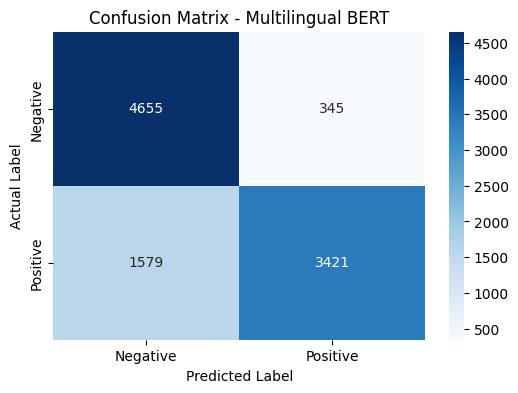

In [69]:
# BERT Confusion Matrix

cm_bert = confusion_matrix(y_test_bert, bert_predictions, labels=["negative", "positive"])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix - Multilingual BERT")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [75]:
# Comparison Table
# Remove old DistilBERT rows if this cell is rerun
results = [r for r in results if r["Model"] != "DistilBERT"]

# Add latest BERT result
results.append({
    "Model": "DistilBERT",
    "Accuracy": bert_accuracy,
    "Precision": bert_precision,
    "Recall": bert_recall,
    "F1-Score": bert_f1
})

comparison_table = pd.DataFrame(results)

print("\nModel Comparison")
print(comparison_table)


Model Comparison
                  Model  Accuracy  Precision  Recall  F1-Score
0     BoW + Naive Bayes    0.8513   0.851422  0.8513  0.851287
1             BoW + SVM    0.8478   0.847800  0.8478  0.847800
2  TF-IDF + Naive Bayes    0.8734   0.873929  0.8734  0.873355
3          TF-IDF + SVM    0.8943   0.894398  0.8943  0.894293
4            DistilBERT    0.8076   0.908391  0.6842  0.780516
